# From Sunlight to Watts
## A First-Principles Derivation of Solar Panel Power Output

---

How much electricity can a solar panel generate over a full year — and how sensitively does the answer depend on how the panel is aimed?

This article answers that question from the ground up: starting with nuclear fusion in the Sun's core, we trace every energy transformation until we reach the kilowatt-hours on your electricity meter. Each step is derived rather than asserted, and the final result is an interactive tool you can tune to your own roof.

### What we need to track

| Quantity | Symbol | Role |
|---|---|---|
| Solar luminosity | $L_\odot$ | Total power radiated by the Sun |
| Earth–Sun distance | $d$ | Sets the irradiance arriving at Earth |
| Solar declination | $\delta$ | Tells us the Sun's latitude on any given day |
| Solar altitude & azimuth | $\alpha$, $A_z$ | Where in your sky the Sun is right now |
| Air mass | AM | How thick an atmosphere the sunlight crosses |
| Panel tilt & azimuth | $\beta$, $\gamma$ | **The main variable: how the panel is oriented** |
| Angle of incidence | $\theta$ | The decisive geometric factor for power |
| Panel area & efficiency | $A$, $\eta$ | The hardware parameters |

### Location parameters

| Parameter | Symbol | Typical range |
|---|---|---|
| Latitude | $\varphi$ | $-90°$ to $+90°$ (N/S) |
| Longitude | $\lambda$ | $-180°$ to $+180°$ (E/W) |
| Elevation | $h$ | 0 – 4000 m |

We will build the calculation layer by layer, introducing each physical concept exactly when it is needed.


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, Output, FloatSlider, IntSlider
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
    print('ipywidgets available — Step 9 will be fully interactive.')
except ImportError:
    HAS_WIDGETS = False
    print('ipywidgets not found — Step 9 will show static plots.')
    print('Install with: pip install ipywidgets')

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'lines.linewidth': 2.0,
    'axes.grid': True, 'grid.alpha': 0.3,
})
SUN_COLOR   = '#F5A623'
SKY_COLOR   = '#4A90D9'
EARTH_COLOR = '#27AE60'
PANEL_COLOR = '#2ECC71'

# ── Physical constants ─────────────────────────────────────────────────────
L_SUN = 3.828e26   # Solar luminosity [W]
AU    = 1.496e11   # 1 Astronomical Unit [m]
S0    = 1361.0     # Solar constant [W/m²]  (derived in Step 1)

print(f'\nPhysical constants loaded.')
print(f'  L_sun = {L_SUN:.3e} W')
print(f'  AU    = {AU:.3e} m')
print(f'  S0    = {S0:.1f} W/m²  (from inverse-square law: {L_SUN/(4*np.pi*AU**2):.1f} W/m²)')

ipywidgets available — Step 9 will be fully interactive.

Physical constants loaded.
  L_sun = 3.828e+26 W
  AU    = 1.496e+11 m
  S0    = 1361.0 W/m²  (from inverse-square law: 1361.1 W/m²)


---

## Step 1 — The Sun as a Power Source

### From nuclear fusion to the Solar Constant

The Sun's energy comes from the **proton–proton chain**: hydrogen nuclei fuse into helium in the core, converting a fraction of their mass into energy via $E = \Delta m\,c^2$. The mass deficit is $\approx 0.7\%$, meaning roughly 4 million tonnes per second are converted to pure energy.

The Sun's total radiated power — its **luminosity** — is measured to be:

$$L_\odot = 3.828 \times 10^{26} \text{ W}$$

This energy radiates outward uniformly in all directions (the Sun is, to high accuracy, an isotropic emitter). At any distance $d$, that power is spread over the surface area of a sphere:

$$I(d) = \frac{L_\odot}{4\pi d^2}$$

This is the **inverse-square law** — one of the most fundamental relations in physics. Every time you double the distance, the irradiance drops by a factor of four.

At Earth's mean distance of 1 Astronomical Unit (AU $= 1.496 \times 10^{11}$ m), this gives the **Solar Constant** $S_0$:

$$\boxed{S_0 = \frac{L_\odot}{4\pi\,\text{AU}^2} \approx 1361 \text{ W/m}^2}$$

$S_0$ is the power per unit area arriving at a surface **perpendicular to the Sun's rays**, just outside Earth's atmosphere. It is the single most important number in solar energy.

> **Intuition check:** $S_0$ is about the power of a small household hair dryer — delivered to every square metre of cross-section facing the Sun, from 150 million kilometres away.

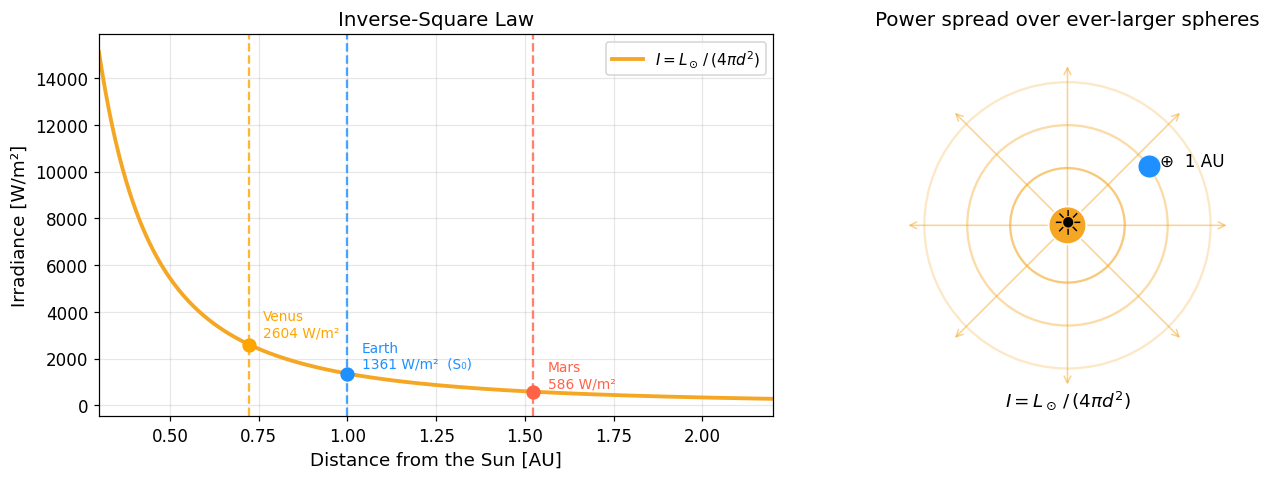

In [2]:
# ── Inverse Square Law visualisation ─────────────────────────────────────
d_AU = np.linspace(0.3, 2.2, 400)
irrad = L_SUN / (4 * np.pi * (d_AU * AU)**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: irradiance vs distance ──────────────────────────────────────────
ax = axes[0]
ax.plot(d_AU, irrad, color=SUN_COLOR, lw=2.5, label='$I = L_\\odot\\,/\\,(4\\pi d^2)$')
for planet, dist, col, label in [
    ('Venus', 0.723, 'orange',     f'{L_SUN/(4*np.pi*(0.723*AU)**2):.0f} W/m²'),
    ('Earth', 1.000, 'dodgerblue', f'{S0:.0f} W/m²  (S₀)'),
    ('Mars',  1.524, 'tomato',     f'{L_SUN/(4*np.pi*(1.524*AU)**2):.0f} W/m²'),
]:
    I_p = L_SUN / (4 * np.pi * (dist * AU)**2)
    ax.axvline(dist, color=col, ls='--', lw=1.5, alpha=0.8)
    ax.scatter([dist], [I_p], color=col, zorder=6, s=70)
    ax.text(dist + 0.04, I_p * 1.08, f'{planet}\n{label}',
            color=col, fontsize=9, va='bottom')
ax.set_xlabel('Distance from the Sun [AU]')
ax.set_ylabel('Irradiance [W/m²]')
ax.set_title('Inverse-Square Law')
ax.legend()
ax.set_xlim(0.3, 2.2)

# ── Right: schematic diagram ──────────────────────────────────────────────
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_xlim(-2, 2); ax2.set_ylim(-2, 2)
ax2.set_title('Power spread over ever-larger spheres')

# Sun at origin
sun = plt.Circle((0,0), 0.18, color=SUN_COLOR, zorder=5)
ax2.add_patch(sun)
ax2.text(0, 0, '☀', ha='center', va='center', fontsize=22, zorder=6)

# Concentric shells
for r, alpha, label in [(0.6, 0.6, ''), (1.05, 0.4, ''), (1.5, 0.25, '')]:
    c = plt.Circle((0,0), r, fill=False, color=SUN_COLOR, alpha=alpha, lw=1.5)
    ax2.add_patch(c)

# Rays
for angle in np.linspace(0, 2*np.pi, 8, endpoint=False):
    ax2.annotate('', xy=(1.7*np.cos(angle), 1.7*np.sin(angle)),
                 xytext=(0.18*np.cos(angle), 0.18*np.sin(angle)),
                 arrowprops=dict(arrowstyle='->', color=SUN_COLOR, alpha=0.5, lw=1))

# Earth
ax2.scatter([1.05*np.cos(np.pi/5)], [1.05*np.sin(np.pi/5)],
             s=180, color='dodgerblue', zorder=7)
ax2.text(1.05*np.cos(np.pi/5)+0.12, 1.05*np.sin(np.pi/5),
          '⊕  1 AU', fontsize=11)

ax2.text(0, -1.9, r'$I = L_\odot\,/\,(4\pi d^2)$',
          ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

---

## Step 2 — Earth's Elliptical Orbit

### How the Earth–Sun distance varies over the year

Earth's orbit is not a perfect circle — it is a slight ellipse, as Kepler's First Law states. The eccentricity is small ($e = 0.0167$, only a 1.7% deviation), but it introduces a seasonal modulation in the top-of-atmosphere irradiance.

From Kepler's laws, the Earth–Sun distance as a function of the day of year $n$ (counting from January 1 = day 1) can be approximated by:

$$\frac{d_0}{d(n)} \approx 1 + e\cos\left(\frac{2\pi(n - n_{\rm peri})}{365.25}\right)$$

where $d_0$ is the mean distance (1 AU) and $n_{\rm peri} \approx 3$ (perihelion, closest approach, occurs around January 3). Since irradiance scales as $d^{-2}$:

$$G_{\rm ext}(n) = S_0 \cdot \left(\frac{d_0}{d(n)}\right)^2 \equiv S_0 \cdot E_0(n)$$

where $E_0(n)$ is the **eccentricity correction factor**. Using the Spencer (1971) harmonic approximation:

$$E_0(n) = 1.000110 + 0.034221\cos B + 0.001280\sin B + 0.000719\cos 2B + 0.000077\sin 2B$$

$$B = \frac{2\pi(n-1)}{365.25} \quad\text{[radians]}$$

The total variation is about $\pm 3.4\%$ around $S_0$. Counterintuitively, Earth is **closest to the Sun in early January** (Northern Hemisphere winter!) — a vivid reminder that seasons are caused by Earth's *tilt*, not by its distance.

$G_{\rm ext}(n)$ is called the **extraterrestrial irradiance (ETR)** — the power per unit area at the top of the atmosphere on a surface perpendicular to the Sun.

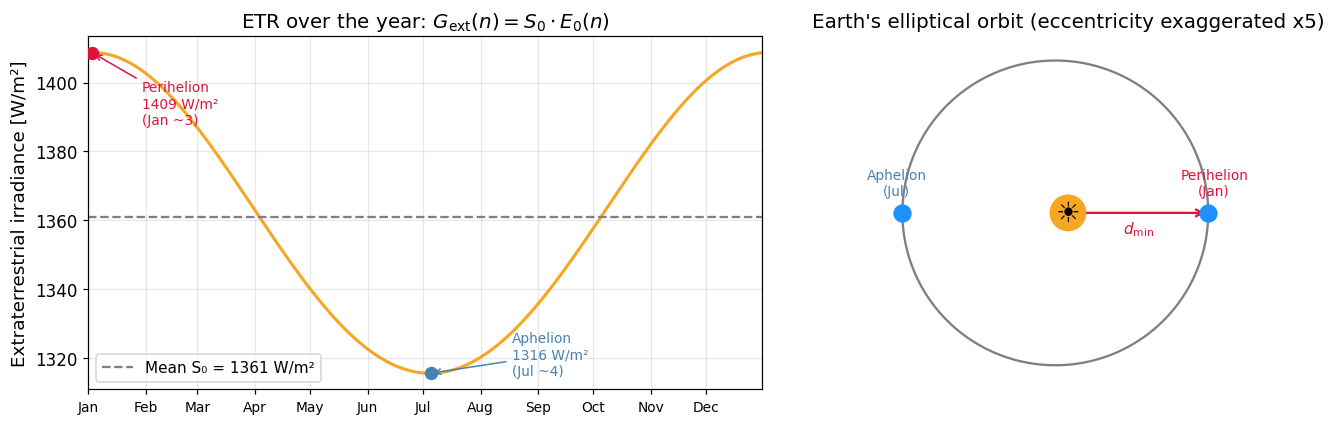

ETR range: 1315.5 - 1408.7 W/m²
Peak-to-peak variation: 93.2 W/m² (6.8%)


In [3]:
# ── Eccentricity correction and ETR ───────────────────────────────────────
def day_angle(doy):
    """Day angle B [radians].  doy = day of year (1-365)."""
    return 2 * np.pi * (doy - 1) / 365.25

def eccentricity_correction(doy):
    """Ratio (d₀/d)²: accounts for Earth's elliptical orbit (Spencer 1971)."""
    B = day_angle(doy)
    return (1.000110 + 0.034221*np.cos(B) + 0.001280*np.sin(B)
            + 0.000719*np.cos(2*B) + 0.000077*np.sin(2*B))

doy = np.arange(1, 366)
E0  = eccentricity_correction(doy)
G_ext = S0 * E0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: ETR over the year ────────────────────────────────────────────────
ax = axes[0]
ax.plot(doy, G_ext, color=SUN_COLOR, lw=2)
ax.axhline(S0, color='gray', ls='--', lw=1.5, label=f'Mean S₀ = {S0:.0f} W/m²')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_days   = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
ax.set_xticks(month_days)
ax.set_xticklabels(month_labels, fontsize=9)

# Mark perihelion and aphelion
i_peri = np.argmax(G_ext)
i_aphe = np.argmin(G_ext)
ax.scatter([doy[i_peri]], [G_ext[i_peri]], color='crimson',  zorder=5, s=60)
ax.scatter([doy[i_aphe]], [G_ext[i_aphe]], color='steelblue', zorder=5, s=60)
ax.annotate(f'Perihelion\n{G_ext[i_peri]:.0f} W/m²\n(Jan ~3)',
             xy=(doy[i_peri], G_ext[i_peri]),
             xytext=(30, 1388), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='crimson'), color='crimson')
ax.annotate(f'Aphelion\n{G_ext[i_aphe]:.0f} W/m²\n(Jul ~4)',
             xy=(doy[i_aphe], G_ext[i_aphe]),
             xytext=(230, 1315), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='steelblue'), color='steelblue')
ax.set_ylabel('Extraterrestrial irradiance [W/m²]')
ax.set_title('ETR over the year: $G_{\\rm ext}(n) = S_0 \\cdot E_0(n)$')
ax.legend()
ax.set_xlim(1, 365)

# ── Right: Earth's orbit (exaggerated) ────────────────────────────────────
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_xlim(-1.8, 1.8); ax2.set_ylim(-1.5, 1.5)
ax2.set_title("Earth's elliptical orbit (eccentricity exaggerated x5)")

# Draw ellipse (exaggerated e=0.083)
e_ex = 0.083
theta_orb = np.linspace(0, 2*np.pi, 400)
a = 1.3
b = a * np.sqrt(1 - e_ex**2)
c = a * e_ex  # focus offset
x_orb = a * np.cos(theta_orb) - c
y_orb = b * np.sin(theta_orb)
ax2.plot(x_orb, y_orb, 'k-', lw=1.5, alpha=0.5)

# Sun at one focus
sun2 = plt.Circle((0, 0), 0.15, color=SUN_COLOR, zorder=5)
ax2.add_patch(sun2)
ax2.text(0, 0, '☀', ha='center', va='center', fontsize=18, zorder=6)

# Earth positions: perihelion (right) and aphelion (left)
peri_x = a - c
aphe_x = -(a + c)
ax2.scatter([peri_x], [0], s=120, color='dodgerblue', zorder=7)
ax2.text(peri_x + 0.05, 0.15, 'Perihelion\n(Jan)', fontsize=9, color='crimson', ha='center')
ax2.scatter([aphe_x], [0], s=120, color='dodgerblue', zorder=7)
ax2.text(aphe_x - 0.05, 0.15, 'Aphelion\n(Jul)', fontsize=9, color='steelblue', ha='center')

# Distance arrows
ax2.annotate('', xy=(peri_x, 0), xytext=(0, 0),
              arrowprops=dict(arrowstyle='<->', color='crimson', lw=1.5))
ax2.text(peri_x/2, -0.18, '$d_{\\rm min}$', color='crimson', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'ETR range: {G_ext.min():.1f} - {G_ext.max():.1f} W/m²')
print(f'Peak-to-peak variation: {G_ext.max()-G_ext.min():.1f} W/m² ({100*(G_ext.max()-G_ext.min())/S0:.1f}%)')

---

## Step 3 — Earth's Axial Tilt and the Seasons

### Deriving the solar declination angle

Earth's spin axis is tilted by $\varepsilon = 23.44°$ relative to the plane of its orbit (the ecliptic). As Earth orbits the Sun, this tilt stays fixed in space (pointing roughly toward Polaris), so the Sun appears to move north and south over the course of a year — a phenomenon we call the **seasons**.

The **declination angle** $\delta$ is the latitude at which the Sun is directly overhead (at solar noon). It ranges from $+23.44°$ (summer solstice, ~June 21) through $0°$ (equinoxes) to $-23.44°$ (winter solstice, ~December 21).

**Geometric derivation:** Consider Earth's orbital motion. The angle swept from the vernal equinox (around March 21, day $n_0 \approx 81$) is:

$$\psi = \frac{360°}{365.25}\,(n - 81)$$

Projecting Earth's tilted axis onto the plane perpendicular to the Sun–Earth line gives:

$$\delta = \arcsin(\sin\varepsilon \cdot \sin\psi) \approx \varepsilon \sin\psi \approx 23.44°\sin\left(\frac{360°}{365.25}(n-81)\right)$$

For higher accuracy (used in our calculations), the Spencer (1971) harmonic series is preferred:

$$\delta = 0.006918 - 0.399912\cos B + 0.070257\sin B - 0.006758\cos 2B + 0.000907\sin 2B - 0.002697\cos 3B + 0.001480\sin 3B$$

where $B = 2\pi(n-1)/365.25$ is the day angle.

Declination tells us **where in the sky** the Sun is at noon — it is the astronomical equivalent of latitude. A panel anywhere on Earth must account for this daily and seasonal drift.

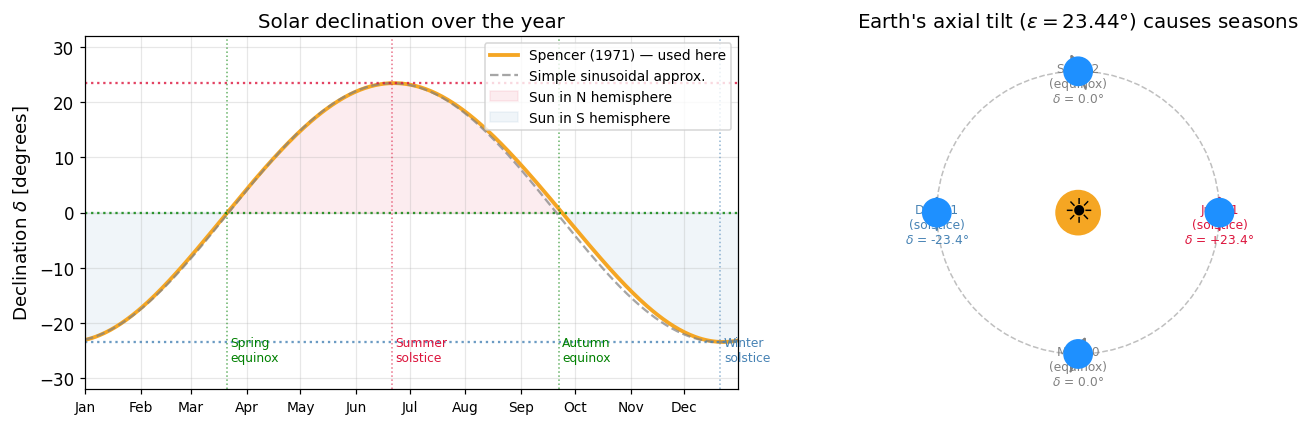

In [4]:
# ── Solar declination ─────────────────────────────────────────────────────
def solar_declination(doy):
    """Solar declination delta [radians]  (Spencer 1971)."""
    B = day_angle(doy)
    return (0.006918
            - 0.399912*np.cos(B)   + 0.070257*np.sin(B)
            - 0.006758*np.cos(2*B) + 0.000907*np.sin(2*B)
            - 0.002697*np.cos(3*B) + 0.001480*np.sin(3*B))

# Simple formula for comparison
def solar_declination_simple(doy):
    psi = np.radians(360/365.25 * (doy - 81))
    return np.radians(23.44) * np.sin(psi)

delta_accurate = np.degrees(solar_declination(doy))
delta_simple   = np.degrees(solar_declination_simple(doy))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: declination over the year ───────────────────────────────────────
ax = axes[0]
ax.plot(doy, delta_accurate, color=SUN_COLOR, lw=2.5, label='Spencer (1971) — used here')
ax.plot(doy, delta_simple,   color='gray',    lw=1.5, ls='--', alpha=0.7,
         label='Simple sinusoidal approx.')

ax.axhline(0,  color='green',  ls=':', lw=1.5, alpha=0.8)
ax.axhline( 23.44,  color='crimson', ls=':', lw=1.5, alpha=0.8)
ax.axhline(-23.44,  color='steelblue', ls=':', lw=1.5, alpha=0.8)

# Mark key dates
for n, label, col in [
    (80,  'Spring\nequinox', 'green'),
    (172, 'Summer\nsolstice', 'crimson'),
    (265, 'Autumn\nequinox', 'green'),
    (355, 'Winter\nsolstice', 'steelblue'),
]:
    ax.axvline(n, color=col, ls=':', lw=1, alpha=0.6)
    ax.text(n+2, -27, label, color=col, fontsize=8)

ax.fill_between(doy, delta_accurate, 0,
                 where=delta_accurate > 0, alpha=0.08, color='crimson', label='Sun in N hemisphere')
ax.fill_between(doy, delta_accurate, 0,
                 where=delta_accurate < 0, alpha=0.08, color='steelblue', label='Sun in S hemisphere')

ax.set_xticks(month_days); ax.set_xticklabels(month_labels, fontsize=9)
ax.set_ylabel('Declination $\\delta$ [degrees]')
ax.set_title('Solar declination over the year')
ax.set_ylim(-32, 32)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(1, 365)

# ── Right: axial tilt schematic ────────────────────────────────────────────
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_xlim(-2.5, 2.5); ax2.set_ylim(-2, 2)
ax2.set_title('Earth\'s axial tilt ($\\varepsilon = 23.44°$) causes seasons')

# Sun
sun3 = plt.Circle((0,0), 0.25, color=SUN_COLOR, zorder=5)
ax2.add_patch(sun3)
ax2.text(0, 0, '☀', ha='center', va='center', fontsize=22, zorder=6)

# Orbit
orb = plt.Circle((0,0), 1.6, fill=False, color='gray', lw=1, ls='--', alpha=0.5)
ax2.add_patch(orb)

# Four Earth positions
eps_r = np.radians(23.44)
for angle, label, col, delta_label in [
    (0,        'Jun 21\n(solstice)',  'crimson',   f'+{23.44:.1f}°'),
    (np.pi/2,  'Sep 22\n(equinox)',  'gray',       '0.0°'),
    (np.pi,    'Dec 21\n(solstice)', 'steelblue',  f'-{23.44:.1f}°'),
    (3*np.pi/2,'Mar 20\n(equinox)',  'gray',       '0.0°'),
]:
    xe = 1.6*np.cos(angle)
    ye = 1.6*np.sin(angle)
    earth = plt.Circle((xe, ye), 0.16, color='dodgerblue', zorder=5)
    ax2.add_patch(earth)
    # Tilt axis
    tilt_dx = 0.25*np.sin(eps_r)*np.cos(angle+np.pi/2)
    tilt_dy = 0.25*np.cos(eps_r)
    ax2.annotate('', xy=(xe+tilt_dx, ye+tilt_dy), xytext=(xe-tilt_dx, ye-tilt_dy),
                  arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
    ax2.text(xe, ye - 0.35, f'{label}\n$\\delta$ = {delta_label}',
              ha='center', fontsize=8, color=col)

plt.tight_layout()
plt.show()

---

## Step 4 — The Sun's Path Across Your Sky

### Solar altitude and azimuth from spherical trigonometry

A ground observer needs to know *where* in the sky the Sun is at any moment. We work in the **local horizontal coordinate system**: altitude $\alpha$ (angle above the horizon) and azimuth $A_z$ (compass direction, measured clockwise from North).

**Ingredients:**
- **Latitude** $\varphi$: the observer's location on Earth
- **Declination** $\delta(n)$: the Sun's celestial latitude (computed above)
- **Hour angle** $\omega$: how far the Sun is from solar noon (Earth rotates at 15°/hour)

The **hour angle** converts clock time to angular position:

$$\omega = 15° \times (T_{\rm solar} - 12)$$

where $T_{\rm solar}$ is **apparent solar time** — which differs from civil time because (a) Earth's orbital speed varies (elliptical orbit) and (b) time zones define constant offsets. The correction, the **Equation of Time** ET($n$), shifts by up to ±16 minutes.

**Applying the spherical law of cosines** to the spherical triangle formed by the zenith, the celestial pole, and the Sun gives:

$$\boxed{\sin\alpha = \sin\varphi\sin\delta + \cos\varphi\cos\delta\cos\omega}$$

This is the key formula: given the observer's latitude $\varphi$, the Sun's declination $\delta$, and the hour angle $\omega$, we get the solar altitude $\alpha$.

For the azimuth, applying the four-parts formula of spherical trigonometry:

$$A_z = \operatorname{atan2}\!\left(\frac{\cos\delta\sin\omega}{\cos\alpha},\; \frac{\sin\delta\cos\varphi - \cos\delta\cos\omega\sin\varphi}{\cos\alpha}\right) \pmod{360°}$$

Sunrise and sunset occur when $\alpha = 0$, giving the **sunrise hour angle**:

$$\omega_s = \arccos(-\tan\varphi\tan\delta)$$

Above the Arctic/Antarctic circles ($|\varphi| > 90° - |\delta|$), this equation has no solution — the Sun never sets (midnight sun) or never rises (polar night).

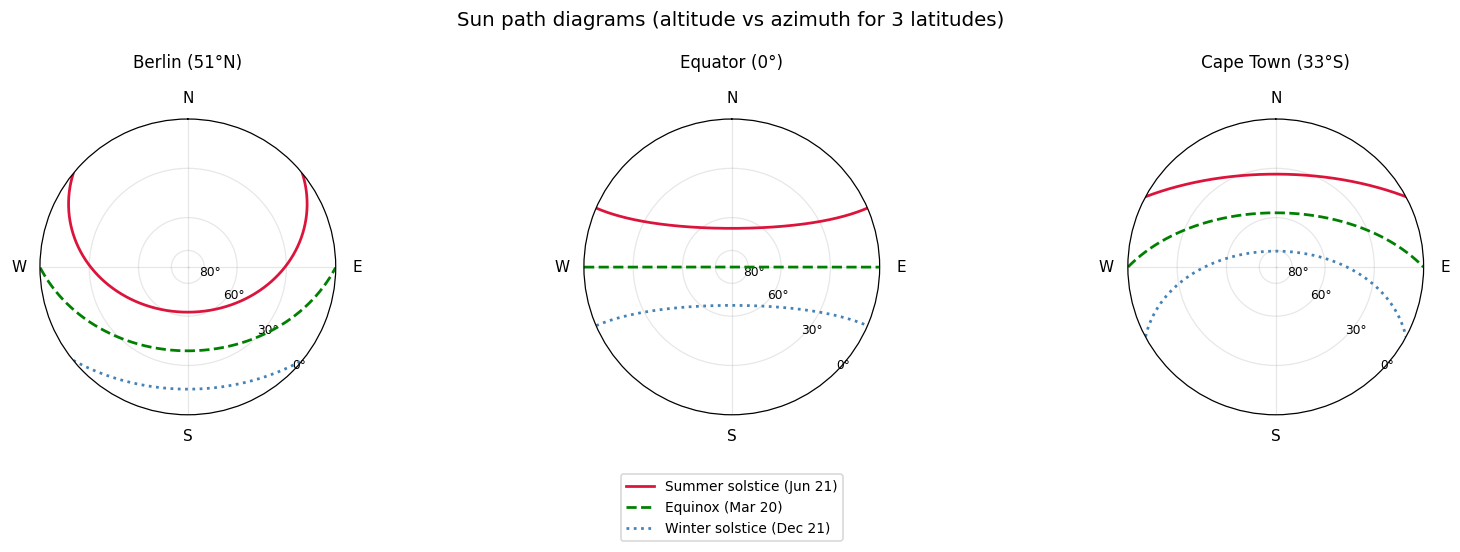

In [5]:
# ── Complete solar position functions (used in all subsequent steps) ───────

def equation_of_time(doy):
    """Equation of time ET [minutes] — converts clock time to solar time."""
    B = day_angle(doy)
    return 229.18 * (0.000075 + 0.001868*np.cos(B) - 0.032077*np.sin(B)
                     - 0.014615*np.cos(2*B) - 0.04089*np.sin(2*B))

def solar_altitude_azimuth(doy, hour_utc, lat_deg, lon_deg):
    """
    Solar altitude alpha [rad] and azimuth Az [rad, from North clockwise].
    Accepts scalars and numpy arrays.
    """
    delta = solar_declination(doy)
    phi   = np.radians(lat_deg)

    # Apparent solar time
    ET      = equation_of_time(doy)           # minutes
    LSM     = np.round(lon_deg / 15.0) * 15.0 # standard meridian [deg]
    t_solar = hour_utc + ET/60.0 + (lon_deg - LSM)/15.0

    # Hour angle (0 at solar noon)
    omega = np.radians(15.0 * (t_solar - 12.0))

    # Altitude
    sin_alt = (np.sin(phi)*np.sin(delta)
               + np.cos(phi)*np.cos(delta)*np.cos(omega))
    altitude = np.arcsin(np.clip(sin_alt, -1.0, 1.0))

    # Azimuth via atan2 (handles all quadrants correctly)
    cos_alt = np.cos(altitude) + 1e-12
    sin_az  = np.cos(delta)*np.sin(omega) / cos_alt
    cos_az  = (np.sin(delta)*np.cos(phi)
               - np.cos(delta)*np.sin(phi)*np.cos(omega)) / cos_alt
    azimuth = np.arctan2(sin_az, cos_az) % (2*np.pi)

    return altitude, azimuth


# ── Sun path diagrams ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5))
spec = gridspec.GridSpec(1, 3, figure=fig)

solstice_summer =  172   # ~June 21
solstice_winter =  355   # ~Dec 21
equinox         =  80    # ~March 20

lats_and_names = [(51, 'Berlin (51°N)'), (0, 'Equator (0°)'), (-33, 'Cape Town (33°S)')]

for col_idx, (lat_deg, name) in enumerate(lats_and_names):
    ax = fig.add_subplot(spec[col_idx], projection='polar')

    hours = np.linspace(0, 24, 1440)  # 1-minute steps

    for doy_plot, label, col, ls in [
        (solstice_summer, 'Summer solstice (Jun 21)', 'crimson',   '-'),
        (equinox,         'Equinox (Mar 20)',          'green',     '--'),
        (solstice_winter, 'Winter solstice (Dec 21)', 'steelblue', ':'),
    ]:
        alt, az = solar_altitude_azimuth(doy_plot, hours, lat_deg, lon_deg=0.0)
        above = alt > 0
        if above.any():
            # Polar plot: theta = azimuth, r = (90 - altitude)
            r   = 90 - np.degrees(alt[above])
            th  = az[above]
            ax.plot(th, r, color=col, ls=ls, lw=1.8, label=label)

    # Style: North at top, East to right (standard sun path convention)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rlim(0, 90)
    ax.set_rlabel_position(135)
    ax.set_rticks([10, 30, 60, 90])
    ax.set_yticklabels(['80°', '60°', '30°', '0°'], fontsize=8)
    cardinal = {0: 'N', np.pi/2: 'E', np.pi: 'S', 3*np.pi/2: 'W'}
    ax.set_xticks(list(cardinal.keys()))
    ax.set_xticklabels(list(cardinal.values()), fontsize=10)
    ax.set_title(name, fontsize=11, pad=15)
    if col_idx == 1:
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45),
                   fontsize=9, ncol=1)

fig.suptitle('Sun path diagrams (altitude vs azimuth for 3 latitudes)',
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## Step 5 — The Atmosphere as a Filter

### Beer-Lambert law, air mass, and clear-sky irradiance

The atmosphere is not transparent. Gases absorb and scatter sunlight — the same physics that makes the sky blue (Rayleigh scattering) and sunsets red (long slant path). We must quantify this attenuation.

#### Air mass

The key geometric quantity is the **air mass** AM: how many atmospheres' worth of gas the beam traverses relative to a vertical path. For a flat Earth with a plane-parallel atmosphere:

$$\text{AM} \approx \frac{1}{\sin\alpha}$$

At solar noon on the equator during an equinox, $\alpha = 90°$ and AM = 1 (the reference condition, called **AM1**). At sunrise/sunset, $\alpha \rightarrow 0$ and AM $\rightarrow \infty$. For large zenith angles, Earth's curvature matters; the **Kasten-Young** empirical formula handles this:

$$\text{AM} = \frac{1}{\sin\alpha + 0.50572\,(\alpha_{\rm deg} + 6.07995)^{-1.6364}}$$

At a site of elevation $h$ metres, the atmosphere above is thinner. The pressure ratio follows a barometric exponential:

$$\text{AM}_{\rm corr} = \text{AM} \times e^{-h/8435}$$

#### Direct Normal Irradiance

The **Beer-Lambert law** describes exponential attenuation by any absorbing medium:

$$I = I_0\,e^{-\tau\cdot\text{AM}}$$

where $\tau$ is the **optical depth** of the atmosphere. For a standard clear sky, the Meinel (1976) empirical approximation works well:

$$\boxed{\text{DNI} = G_{\rm ext} \times 0.7^{\text{AM}^{0.678}}}$$

Here DNI is the **Direct Normal Irradiance** — the beam arriving at a surface perpendicular to the Sun's direction. At AM1, $\text{DNI} = 1361 \times 0.7 \approx 953$ W/m² on a clear day.

#### Diffuse Horizontal Irradiance

Scattered photons (primarily from the sky dome) contribute a **diffuse** component DHI. For a clear sky, this is roughly 10–15% of the beam component. We use:

$$\text{DHI} \approx 0.1\,G_{\rm ext}\sin\alpha$$

The total irradiance on a horizontal surface is the **Global Horizontal Irradiance**:

$$\text{GHI} = \text{DNI}\sin\alpha + \text{DHI}$$

> **Note:** Real-world calculations use turbidity models (aerosols, humidity, clouds). This clear-sky model gives a useful upper bound; actual annual yields are typically 60–85% of the clear-sky prediction depending on local climate.

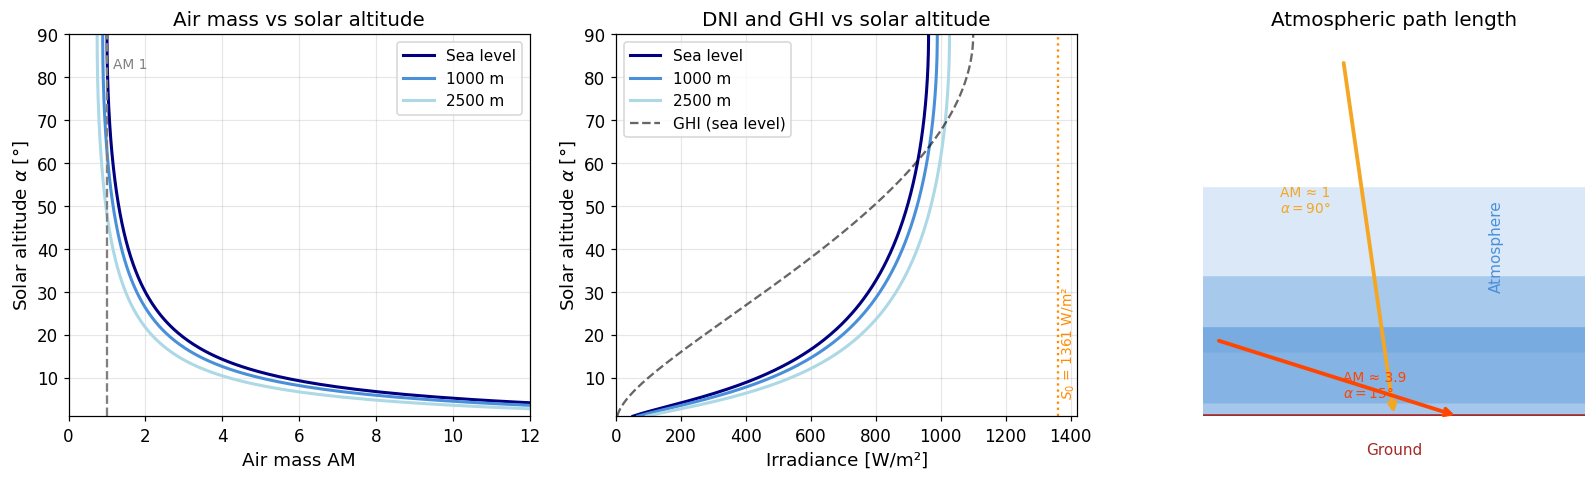

At alpha=45° (sea level):  DNI=867, DHI=96, GHI=709 W/m²


In [6]:
# ── Air mass and clear-sky irradiance functions ────────────────────────────

def air_mass(altitude_rad, elevation_m=0.0):
    """
    Kasten-Young air mass, corrected for site elevation.
    altitude_rad: solar altitude in radians (must be > 0)
    elevation_m : site elevation in metres
    """
    alt_deg = np.degrees(altitude_rad)
    denom   = (np.sin(altitude_rad)
               + 0.50572 * np.maximum(alt_deg + 6.07995, 0.01)**(-1.6364))
    AM_sl   = np.where(alt_deg > 0.0, 1.0/denom, np.inf)
    return AM_sl * np.exp(-elevation_m / 8435.0)

def clear_sky(G_ext, altitude_rad, elevation_m=0.0):
    """
    Clear-sky irradiance components [W/m²].
    Returns: DNI, DHI, GHI
    DNI: Direct Normal Irradiance  (Meinel 1976 model)
    DHI: Diffuse Horizontal Irradiance  (~10% clear-sky approximation)
    GHI: Global Horizontal Irradiance
    """
    daytime = altitude_rad > 0.0
    AM      = air_mass(altitude_rad, elevation_m)
    AM_clip = np.minimum(AM, 38.0)          # prevent overflow

    DNI = np.where(daytime, G_ext * 0.7**(AM_clip**0.678), 0.0)
    DHI = np.where(daytime, 0.1 * G_ext * np.sin(altitude_rad), 0.0)
    GHI = DNI * np.where(daytime, np.sin(altitude_rad), 0.0) + DHI
    return DNI, DHI, GHI


# ── Visualise atmospheric effects ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

alt_deg_arr = np.linspace(1, 90, 300)
alt_rad_arr = np.radians(alt_deg_arr)
G_ext_noon  = S0 * 1.01   # ~ETR near equinox

# ── Left: Air mass vs altitude (altitude on y-axis: 90° = sun overhead) ───
ax = axes[0]
for h, col, lbl in [(0, 'navy', 'Sea level'), (1000, SKY_COLOR, '1000 m'),
                     (2500, 'lightblue', '2500 m')]:
    AM = air_mass(alt_rad_arr, h)
    ax.plot(AM, alt_deg_arr, color=col, lw=2, label=lbl)
ax.axvline(1, color='gray', ls='--', lw=1.5)
ax.text(1.15, 82, 'AM 1', color='gray', fontsize=9)
ax.set_xlabel('Air mass AM')
ax.set_ylabel('Solar altitude $\\alpha$ [°]')
ax.set_title('Air mass vs solar altitude')
ax.set_xlim(0, 12); ax.set_ylim(1, 90)
ax.legend()

# ── Centre: DNI vs altitude (altitude on y-axis) ───────────────────────────
ax2 = axes[1]
for h, col, lbl in [(0, 'navy', 'Sea level'), (1000, SKY_COLOR, '1000 m'),
                     (2500, 'lightblue', '2500 m')]:
    DNI, DHI, GHI = clear_sky(G_ext_noon, alt_rad_arr, h)
    ax2.plot(DNI, alt_deg_arr, color=col, lw=2, label=lbl)
ax2.plot(clear_sky(G_ext_noon, alt_rad_arr, 0)[2], alt_deg_arr,
          'k--', lw=1.5, alpha=0.6, label='GHI (sea level)')
ax2.axvline(S0, color='darkorange', ls=':', lw=1.5)
ax2.text(S0*1.005, 5, f'$S_0$ = {S0:.0f} W/m²',
          color='darkorange', fontsize=9, rotation=90, va='bottom')
ax2.set_xlabel('Irradiance [W/m²]')
ax2.set_ylabel('Solar altitude $\\alpha$ [°]')
ax2.set_title('DNI and GHI vs solar altitude')
ax2.set_xlim(0, 1420); ax2.set_ylim(1, 90)
ax2.legend()

# ── Right: Beer-Lambert schematic ──────────────────────────────────────────
ax3 = axes[2]
ax3.set_xlim(-1.5, 1.5); ax3.set_ylim(0, 3)
ax3.set_aspect('equal')
ax3.axis('off')
ax3.set_title('Atmospheric path length')

# Atmosphere bands
for y_bot, y_top, col, alpha in [(0, 0.4, SKY_COLOR, 0.5),
                                    (0.4, 0.8, SKY_COLOR, 0.35),
                                    (0.8, 1.5, SKY_COLOR, 0.2),
                                    (1.5, 3.0, 'white', 0.0)]:
    rect = mpatches.FancyBboxPatch((-1.5, y_bot), 3.0, y_top-y_bot,
                                    facecolor=col, alpha=alpha, edgecolor='none')
    ax3.add_patch(rect)

# Ground
ax3.axhline(0, color='brown', lw=3)

# Two rays: overhead and low-angle
ax3.annotate('', xy=(0.0, 0.0), xytext=(-0.4, 2.8),
              arrowprops=dict(arrowstyle='->', color=SUN_COLOR, lw=2.5))
ax3.text(-0.7, 1.6, 'AM ≈ 1\n$\\alpha=90°$', color=SUN_COLOR, fontsize=9, ha='center')

ax3.annotate('', xy=(0.5, 0.0), xytext=(-1.4, 0.6),
              arrowprops=dict(arrowstyle='->', color='orangered', lw=2.5))
ax3.text(-0.4, 0.15, 'AM ≈ 3.9\n$\\alpha=15°$', color='orangered', fontsize=9)

ax3.text(0, -0.3, 'Ground', ha='center', color='brown', fontsize=10)
ax3.text(0.8, 1.0, 'Atmosphere', ha='center', color=SKY_COLOR, fontsize=10,
          rotation=90)

plt.tight_layout()
plt.show()

alt_test = np.radians(45)
DNI_t, DHI_t, GHI_t = clear_sky(S0, alt_test, 0)
print(f'At alpha=45° (sea level):  DNI={DNI_t:.0f}, DHI={DHI_t:.0f}, GHI={GHI_t:.0f} W/m²')

---

## Step 6 — Irradiance on a Tilted Panel

### Angle of incidence from vector geometry

A solar panel intercepts sunlight according to the **cosine law**: if the Sun's rays make an angle $\theta$ with the panel's normal vector, the irradiance hitting the panel is reduced by $\cos\theta$.

We describe the panel's orientation with two angles:
- **Tilt** $\beta$: angle from horizontal (0° = flat, 90° = vertical)
- **Azimuth** $\gamma$: compass direction the panel faces (clockwise from North; South = 180°)

**Deriving $\cos\theta$ from first principles.** In the local horizontal coordinate system (x = East, y = North, z = Up), the unit vector pointing **toward the Sun** is:

$$\hat{s} = \begin{pmatrix}\cos\alpha\sin A_z \\ \cos\alpha\cos A_z \\ \sin\alpha\end{pmatrix}$$

The panel's outward **normal vector** (pointing toward the sky side of the panel, tilted $\beta$ from vertical, facing azimuth $\gamma$) is:

$$\hat{n} = \begin{pmatrix}\sin\beta\sin\gamma \\ \sin\beta\cos\gamma \\ \cos\beta\end{pmatrix}$$

The angle of incidence $\theta$ is given by the dot product $\hat{s}\cdot\hat{n}$:

$$\cos\theta = \hat{s}\cdot\hat{n} = \sin\alpha\cos\beta + \cos\alpha\sin\beta\cos(A_z - \gamma)$$

This elegant formula encodes all the geometry. Note:
- For a **horizontal panel** ($\beta = 0$): $\cos\theta = \sin\alpha$ — the familiar result for a flat surface.
- For a **vertical south-facing panel** ($\beta = 90°$, $\gamma = 180°$) at solar noon ($A_z = 180°$): $\cos\theta = \cos\alpha$ — the Sun shines most directly when it is lowest.

### Three components of panel irradiance

A tilted panel receives light from three sources (the **isotropic sky model** of Liu & Jordan, 1963):

$$\boxed{G_T = \underbrace{\text{DNI}\cdot\cos\theta}_{\text{direct beam}} + \underbrace{\text{DHI}\cdot\frac{1+\cos\beta}{2}}_{\text{sky diffuse}} + \underbrace{\text{GHI}\cdot\rho\cdot\frac{1-\cos\beta}{2}}_{\text{ground-reflected}}}$$

where $\rho \approx 0.2$ is the ground **albedo** (reflectivity). The $(1+\cos\beta)/2$ factor is the **view factor** to the sky dome — a flat panel ($\beta=0$) sees the full hemisphere; a vertical panel sees only half.

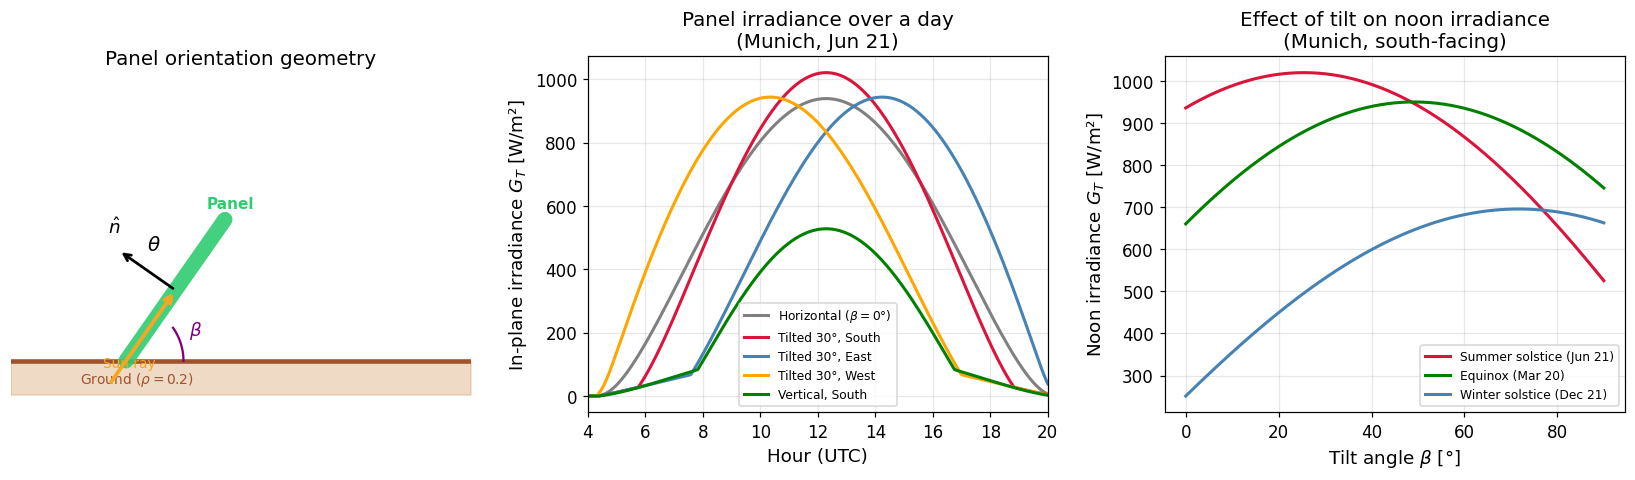

In [7]:
# ── Panel irradiance function ──────────────────────────────────────────────

def panel_irradiance(DNI, DHI, GHI, altitude_rad, azimuth_rad,
                      tilt_deg, panel_az_deg, albedo=0.20):
    """
    Total in-plane irradiance [W/m²]  (isotropic sky / Liu-Jordan model).

    tilt_deg    : 0 = horizontal, 90 = vertical
    panel_az_deg: facing direction, degrees from North clockwise
                  South = 180, East = 90, West = 270
    albedo      : ground reflectivity (0.2 = grass/concrete, 0.6 = snow)
    """
    beta  = np.radians(tilt_deg)
    gamma = np.radians(panel_az_deg)

    # Angle of incidence: dot product of sun vector and panel normal
    cos_theta = (np.sin(altitude_rad)*np.cos(beta)
                 + np.cos(altitude_rad)*np.sin(beta)
                   *np.cos(azimuth_rad - gamma))
    cos_theta = np.where(altitude_rad > 0.0, np.clip(cos_theta, 0.0, 1.0), 0.0)

    G_direct  = DNI * cos_theta                               # beam
    G_sky     = DHI * (1.0 + np.cos(beta)) / 2.0             # sky diffuse
    G_ground  = GHI * albedo * (1.0 - np.cos(beta)) / 2.0   # ground-reflected
    return G_direct + G_sky + G_ground


# ── Panel orientation diagram ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Left: geometry schematic ──────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.3, 2.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Panel orientation geometry')

# Ground
ax.axhline(0, color='sienna', lw=3)
ax.fill_between([-0.5, 3.5], [-0.3, -0.3], [0, 0], color='peru', alpha=0.3)
ax.text(0.1, -0.2, 'Ground ($\\rho = 0.2$)', color='sienna', fontsize=9)

# Panel (tilted at 35 deg, south-facing)
beta_demo = np.radians(35)
px_start, py_start = 0.5, 0
px_end = px_start + 1.5*np.cos(np.pi/2 - beta_demo)
py_end = py_start + 1.5*np.sin(np.pi/2 - beta_demo)
ax.plot([px_start, px_end], [py_start, py_end],
         color=PANEL_COLOR, lw=10, solid_capstyle='round', alpha=0.9)
ax.text(px_start + 0.7, py_end + 0.1, 'Panel', color=PANEL_COLOR,
         fontsize=10, fontweight='bold')

# Normal vector
mid_x = (px_start + px_end)/2
mid_y = (py_start + py_end)/2
nx = -np.sin(np.pi/2 - beta_demo)
ny =  np.cos(np.pi/2 - beta_demo)
ax.annotate('', xy=(mid_x + 0.6*nx, mid_y + 0.6*ny), xytext=(mid_x, mid_y),
              arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
ax.text(mid_x + 0.65*nx, mid_y + 0.65*ny + 0.12,
         '$\\hat{n}$', fontsize=12, ha='center')

# Sun ray
alpha_demo = np.radians(55)
sx = np.cos(alpha_demo)  # from South (left in diagram)
sy = np.sin(alpha_demo)
ax.annotate('', xy=(mid_x, mid_y),
              xytext=(mid_x - 1.0*sx, mid_y - 1.0*sy),
              arrowprops=dict(arrowstyle='->', color=SUN_COLOR, lw=2.5))
ax.text(mid_x - 1.1*sx, mid_y - 1.0*sy + 0.15, 'Sun ray', color=SUN_COLOR, fontsize=9)

# Angle theta
theta_demo_deg = abs(np.degrees(beta_demo) - (90 - np.degrees(alpha_demo)))
arc_t = np.linspace(np.pi/2 - beta_demo + np.pi,
                     np.pi/2 - beta_demo + np.pi - np.radians(theta_demo_deg), 30)
ax.plot(mid_x + 0.3*np.cos(arc_t), mid_y + 0.3*np.sin(arc_t), 'k-', lw=1.5)
ax.text(mid_x - 0.25, mid_y + 0.35, '$\\theta$', fontsize=13, color='black')

# Tilt angle
arc_b = np.linspace(0, beta_demo, 30)
ax.plot(px_start + 0.5*np.cos(arc_b), px_start*0 + 0.5*np.sin(arc_b), color='purple', lw=1.5)
ax.text(px_start + 0.55, 0.22, '$\\beta$', color='purple', fontsize=12)

# ── Centre: cos(theta) over a day ─────────────────────────────────────────
ax2 = axes[1]
hours_day = np.linspace(4, 20, 500)
doy_eq = 172  # summer solstice
lat_demo, lon_demo = 48.0, 11.0  # Munich

alt_d, az_d = solar_altitude_azimuth(doy_eq, hours_day, lat_demo, lon_demo)
DNI_d, DHI_d, GHI_d = clear_sky(S0 * eccentricity_correction(doy_eq), alt_d, 0)

for tilt, panel_az, col, lbl in [
    (0,   180, 'gray',      'Horizontal ($\\beta=0°$)'),
    (30,  180, 'crimson',   'Tilted 30°, South'),
    (30,   90, 'steelblue', 'Tilted 30°, East'),
    (30,  270, 'orange',    'Tilted 30°, West'),
    (90,  180, 'green',     'Vertical, South'),
]:
    G_T = panel_irradiance(DNI_d, DHI_d, GHI_d, alt_d, az_d, tilt, panel_az)
    ax2.plot(hours_day, G_T, color=col, lw=2, label=lbl)

ax2.set_xlabel('Hour (UTC)')
ax2.set_ylabel('In-plane irradiance $G_T$ [W/m²]')
ax2.set_title(f'Panel irradiance over a day\n(Munich, Jun 21)')
ax2.legend(fontsize=8)
ax2.set_xlim(4, 20)

# ── Right: Tilt effect at noon ────────────────────────────────────────────
ax3 = axes[2]
tilts = np.linspace(0, 90, 181)
lat_r = np.radians(lat_demo)

for doy_t, label, col in [
    (172, 'Summer solstice (Jun 21)', 'crimson'),
    (80,  'Equinox (Mar 20)',         'green'),
    (355, 'Winter solstice (Dec 21)', 'steelblue'),
]:
    # Solar noon position
    alt_noon, az_noon = solar_altitude_azimuth(doy_t, 12.0, lat_demo, lon_demo)
    G_ext_t = S0 * eccentricity_correction(doy_t)
    DNI_n, DHI_n, GHI_n = clear_sky(G_ext_t, np.array([alt_noon]), 0)
    G_T_arr = panel_irradiance(DNI_n, DHI_n, GHI_n,
                                np.array([alt_noon]), np.array([az_noon]),
                                tilts, 180)
    ax3.plot(tilts, G_T_arr, color=col, lw=2, label=label)

ax3.set_xlabel('Tilt angle $\\beta$ [°]')
ax3.set_ylabel('Noon irradiance $G_T$ [W/m²]')
ax3.set_title('Effect of tilt on noon irradiance\n(Munich, south-facing)')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

---

## Step 7 — From Irradiance to Electrical Power

### Panel efficiency and temperature correction

The in-plane irradiance $G_T$ tells us how much sunlight hits the panel. Converting that to **electrical power** involves two more factors:

**1. Panel area and efficiency:**

$$P = A \times \eta \times G_T$$

where $A$ [m²] is the active panel area and $\eta$ is the **conversion efficiency** — the fraction of incident light energy converted to electricity. Modern silicon solar panels achieve $\eta = 17{-}23\%$ at standard test conditions (STC: $G_T = 1000$ W/m², $T_{\rm cell} = 25°$C).

**2. Temperature correction:**

Solar cells lose efficiency when they heat up — a well-known semiconductor effect. The relationship is approximately linear:

$$\eta(T_{\rm cell}) = \eta_{\rm STC}\,\left[1 - \gamma_T\,(T_{\rm cell} - 25°C)\right]$$

where $\gamma_T \approx 0.004\,/°C$ (monocrystalline silicon). A panel at 60°C operates at $1 - 0.004 \times 35 = 86\%$ of its rated efficiency.

The cell temperature is estimated from the **NOCT** (Nominal Operating Cell Temperature, typically 45°C):

$$T_{\rm cell} = T_{\rm ambient} + \frac{\text{NOCT} - 20}{800}\,G_T$$

In practice, this temperature correction reduces annual yield by roughly **5–12%** in hot climates.

**The full instantaneous power equation:**

$$\boxed{P(n,t) = A\,\eta_{\rm STC}\left[1 - \gamma_T\left(T_{\rm amb} + \frac{\text{NOCT}-20}{800}G_T - 25\right)\right]G_T}$$

> For simplicity in the annual integration below, we use fixed $\eta$ (a reasonable approximation for mild-climate annual averages). Toggle the parameter in the interactive step to see the temperature effect.

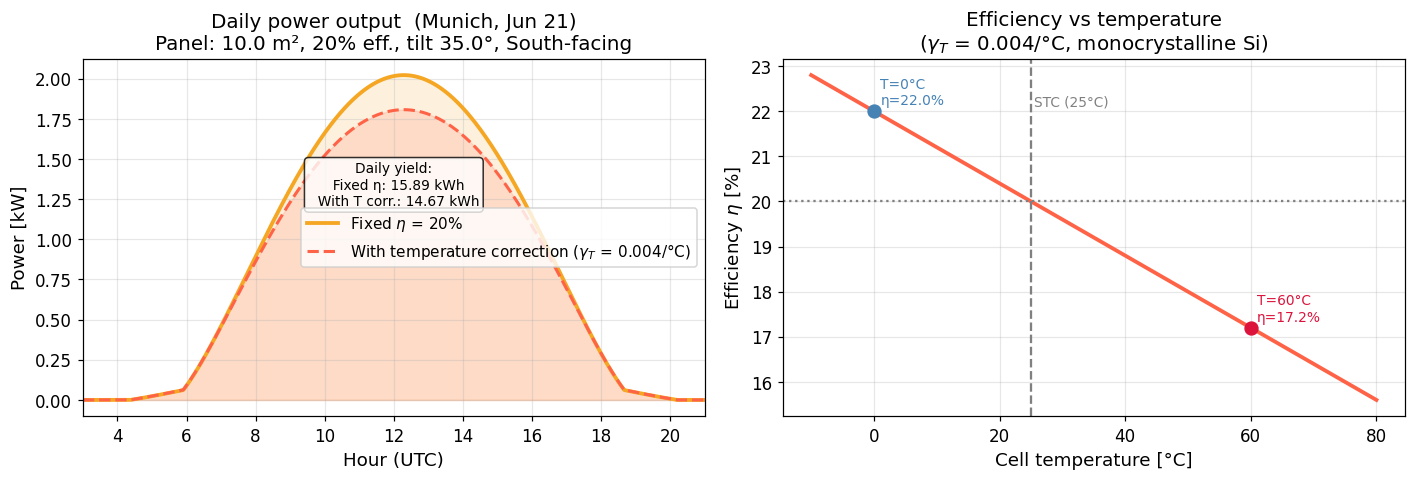

In [8]:
# ── Daily power profile with and without temperature correction ────────────

AREA       = 10.0    # m²
ETA_STC    = 0.20    # efficiency at STC (20%)
GAMMA_T    = 0.004   # temperature coefficient [/°C]
NOCT       = 45.0    # °C
T_AMB      = 20.0    # °C  (assumed constant for demonstration)

doy_demo   = 172     # June 21
lat_demo   = 48.0
lon_demo   = 11.0
tilt_demo  = 35.0
az_demo    = 180.0   # South
G_ext_demo = S0 * eccentricity_correction(doy_demo)

hours_fine = np.linspace(3, 21, 1000)
alt_f, az_f = solar_altitude_azimuth(doy_demo, hours_fine, lat_demo, lon_demo)
DNI_f, DHI_f, GHI_f = clear_sky(G_ext_demo, alt_f, 0)
G_T_f = panel_irradiance(DNI_f, DHI_f, GHI_f, alt_f, az_f, tilt_demo, az_demo)

# Power without temperature correction
P_fixed = AREA * ETA_STC * G_T_f

# Power with temperature correction
T_cell = T_AMB + (NOCT - 20) / 800.0 * G_T_f
eta_T  = ETA_STC * (1 - GAMMA_T * (T_cell - 25.0))
P_temp = AREA * eta_T * G_T_f

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: Power profile ────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(hours_fine, P_fixed/1000, alpha=0.15, color=SUN_COLOR)
ax.plot(hours_fine, P_fixed/1000, color=SUN_COLOR, lw=2.5,
         label=f'Fixed $\\eta$ = {ETA_STC*100:.0f}%')
ax.fill_between(hours_fine, P_temp/1000, alpha=0.15, color='tomato')
ax.plot(hours_fine, P_temp/1000, color='tomato', lw=2, ls='--',
         label=f'With temperature correction ($\\gamma_T$ = {GAMMA_T}/°C)')

ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Power [kW]')
ax.set_title(f'Daily power output  (Munich, Jun 21)\n'
              f'Panel: {AREA} m², {ETA_STC*100:.0f}% eff., tilt {tilt_demo}°, South-facing')
ax.legend()
ax.set_xlim(3, 21)

E_fixed = np.trapezoid(P_fixed/1000, hours_fine)
E_temp  = np.trapezoid(P_temp/1000, hours_fine)
ax.text(12, max(P_fixed)/1000*0.6,
         f'Daily yield:\n  Fixed η: {E_fixed:.2f} kWh\n  With T corr.: {E_temp:.2f} kWh',
         ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Right: Efficiency vs temperature ──────────────────────────────────────
ax2 = axes[1]
T_range = np.linspace(-10, 80, 200)
eta_range = ETA_STC * (1 - GAMMA_T * (T_range - 25))
ax2.plot(T_range, eta_range * 100, color='tomato', lw=2.5)
ax2.axvline(25, color='gray', ls='--', lw=1.5)
ax2.text(25.5, eta_range[0]*100*0.97, 'STC (25°C)', color='gray', fontsize=9)
ax2.axhline(ETA_STC*100, color='gray', ls=':', lw=1.5)
for T_mark, col in [(0, 'steelblue'), (60, 'crimson')]:
    eta_m = ETA_STC * (1 - GAMMA_T * (T_mark - 25))
    ax2.scatter([T_mark], [eta_m*100], color=col, s=70, zorder=5)
    ax2.text(T_mark+1, eta_m*100+0.15,
              f'T={T_mark}°C\nη={eta_m*100:.1f}%', color=col, fontsize=9)
ax2.set_xlabel('Cell temperature [°C]')
ax2.set_ylabel('Efficiency $\\eta$ [%]')
ax2.set_title(f'Efficiency vs temperature\n($\\gamma_T$ = {GAMMA_T}/°C, monocrystalline Si)')

plt.tight_layout()
plt.show()

---

## Step 8 — Annual Energy: Integrating Over a Full Year

### Putting it all together

We now have all the pieces. The **annual electrical energy yield** is:

$$E_{\rm annual} = \int_0^{365}\int_0^{24} P(n,\,t)\;dt\;dn$$

where $P(n, t)$ is the instantaneous power on day $n$ at hour $t$:

$$P(n,t) = A\,\eta\,G_T\!\left[\alpha(n,t,\varphi,\lambda),\;A_z(n,t,\varphi,\lambda),\;\beta,\;\gamma\right]$$

$$G_T = \text{DNI}(G_{\rm ext}(n),\,\text{AM}(\alpha,\,h))\cdot\cos\theta(\alpha, A_z, \beta, \gamma) + \text{DHI}\cdot\frac{1+\cos\beta}{2} + \text{GHI}\cdot\rho\cdot\frac{1-\cos\beta}{2}$$

This integral has no closed form — every link in the chain depends on time in a different way. We evaluate it **numerically** using a midpoint Riemann sum with 30-minute time steps ($\Delta t = 0.5$ h):

$$E_{\rm annual} \approx \sum_{n=1}^{365}\sum_{k=1}^{48} P(n,\,t_k)\,\Delta t$$

The full computation is vectorised over all days and hours simultaneously, then looped over the tilt values of the orientation grid.

The heatmap below shows **annual yield as a function of tilt $\beta$ and azimuth $\gamma$** — the two orientation parameters an installer can choose. The optimal orientation is marked with a star.

Computing annual energy grid for Munich (48°N, 11°E) ...


Optimal tilt:    40°
Optimal azimuth: 180°  (180° = South)
Annual yield at optimal: 4467.4 kWh  (for 10.0 m², 20% eff.)
Annual yield horizontal: 3515.7 kWh
Gain from tilting:       27.1%


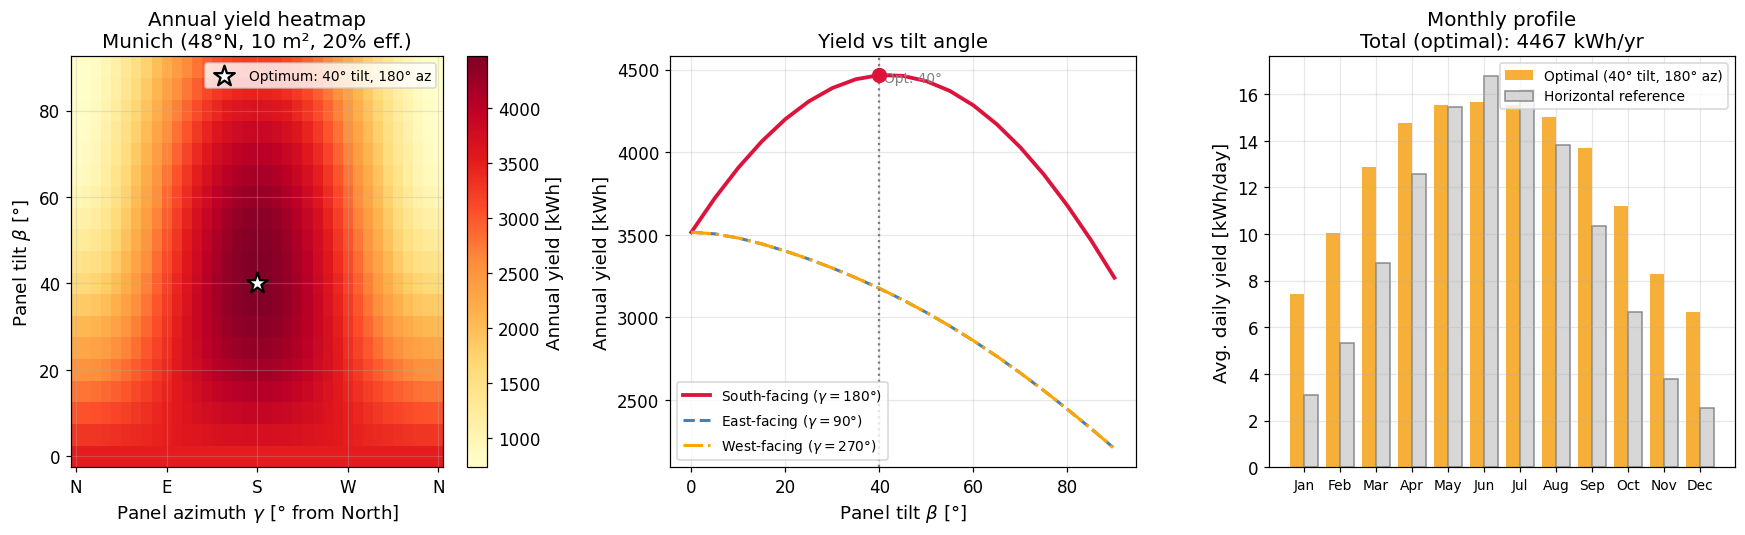

In [9]:
# ── Vectorised annual energy computation ───────────────────────────────────

# Days per month (non-leap year) — used to normalise monthly totals to kWh/day
DAYS_PER_MONTH = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
MONTH_LABELS   = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']

def compute_annual_grid(lat_deg, lon_deg, elevation_m,
                         tilt_arr, az_arr,
                         area_m2=1.0, efficiency=0.20, albedo=0.20, dt=0.5):
    """
    Annual energy [kWh] for a 2-D grid of (tilt, azimuth) orientations.
    Returns array of shape (len(tilt_arr), len(az_arr)).
    Uses midpoint Riemann sum with time step dt [hours].
    """
    hours = np.arange(dt/2, 24.0, dt)                  # midpoints
    days  = np.arange(1, 366)
    DOY, HOUR = np.meshgrid(days, hours, indexing='ij') # shape (365, 48)

    # Solar position and irradiance for all (day, hour) — computed once
    G_ext = S0 * eccentricity_correction(DOY)
    alt, az = solar_altitude_azimuth(DOY, HOUR, lat_deg, lon_deg)
    DNI, DHI, GHI = clear_sky(G_ext, alt, elevation_m)

    beta_r  = np.radians(tilt_arr)   # (n_tilt,)
    gamma_r = np.radians(az_arr)     # (n_az,)

    energy = np.zeros((len(tilt_arr), len(az_arr)))

    for i, beta in enumerate(beta_r):
        # Vectorise over all azimuths at once — shape (n_az, 365, 48)
        cos_th = (np.sin(alt)*np.cos(beta)
                  + np.cos(alt)*np.sin(beta)
                    *np.cos(az[np.newaxis,:,:] - gamma_r[:,np.newaxis,np.newaxis]))
        cos_th = np.where(alt[np.newaxis,:,:] > 0, np.clip(cos_th, 0, 1), 0)

        G_b = DNI[np.newaxis,:,:] * cos_th
        G_s = DHI[np.newaxis,:,:] * (1 + np.cos(beta)) / 2
        G_g = GHI[np.newaxis,:,:] * albedo * (1 - np.cos(beta)) / 2
        G_T = G_b + G_s + G_g

        energy[i, :] = np.sum(area_m2 * efficiency * G_T, axis=(1,2)) * dt / 1000

    return energy


def compute_monthly_energy(lat_deg, lon_deg, elevation_m,
                            tilt_deg, panel_az_deg,
                            area_m2=1.0, efficiency=0.20, albedo=0.20, dt=0.5):
    """Monthly energy yield [kWh] — array of 12 values."""
    boundaries = [1,32,60,91,121,152,182,213,244,274,305,335,366]
    monthly = []
    for i in range(12):
        days  = np.arange(boundaries[i], boundaries[i+1])
        hours = np.arange(dt/2, 24.0, dt)
        DOY, HOUR = np.meshgrid(days, hours, indexing='ij')
        G_ext = S0 * eccentricity_correction(DOY)
        alt, az = solar_altitude_azimuth(DOY, HOUR, lat_deg, lon_deg)
        DNI, DHI, GHI = clear_sky(G_ext, alt, elevation_m)
        G_T = panel_irradiance(DNI, DHI, GHI, alt, az, tilt_deg, panel_az_deg, albedo)
        monthly.append(np.sum(area_m2 * efficiency * G_T) * dt / 1000)
    return np.array(monthly)


# ── Compute orientation grid for Munich ───────────────────────────────────
print('Computing annual energy grid for Munich (48°N, 11°E) ...')
lat_m, lon_m, elev_m = 48.0, 11.0, 520.0
area_m2 = 10.0   # m²
eta     = 0.20   # 20% efficiency

tilt_arr = np.arange(0, 91, 5)    # 0, 5, 10, ..., 90 degrees
az_arr   = np.arange(0, 361, 10)  # 0, 10, 20, ..., 360 degrees

energy_grid = compute_annual_grid(lat_m, lon_m, elev_m, tilt_arr, az_arr,
                                   area_m2=area_m2, efficiency=eta)

i_opt, j_opt = np.unravel_index(np.argmax(energy_grid), energy_grid.shape)
E_max = energy_grid[i_opt, j_opt]
E_flat = energy_grid[0, 0]  # horizontal panel (all azimuths equal at beta=0)

print(f'Optimal tilt:    {tilt_arr[i_opt]}°')
print(f'Optimal azimuth: {az_arr[j_opt]}°  (180° = South)')
print(f'Annual yield at optimal: {E_max:.1f} kWh  (for {area_m2} m², {eta*100:.0f}% eff.)')
print(f'Annual yield horizontal: {E_flat:.1f} kWh')
print(f'Gain from tilting:       {100*(E_max-E_flat)/E_flat:.1f}%')

# ── Heatmap visualisation ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: orientation heatmap ─────────────────────────────────────────────
ax = axes[0]
im = ax.pcolormesh(az_arr, tilt_arr, energy_grid,
                    cmap='YlOrRd', shading='auto')
plt.colorbar(im, ax=ax, label='Annual yield [kWh]')
ax.scatter([az_arr[j_opt]], [tilt_arr[i_opt]], s=200, marker='*',
            color='white', edgecolors='black', lw=1.5, zorder=5,
            label=f'Optimum: {tilt_arr[i_opt]}° tilt, {az_arr[j_opt]}° az')
ax.set_xlabel('Panel azimuth $\\gamma$ [° from North]')
ax.set_ylabel('Panel tilt $\\beta$ [°]')
ax.set_title(f'Annual yield heatmap\nMunich (48°N, {area_m2:.0f} m², {eta*100:.0f}% eff.)')
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
ax.legend(fontsize=9, loc='upper right')

# ── Centre: tilt sweep (south-facing) ─────────────────────────────────────
ax2 = axes[1]
j_south = np.argmin(np.abs(az_arr - 180))
ax2.plot(tilt_arr, energy_grid[:, j_south], color='crimson', lw=2.5,
          label='South-facing ($\\gamma = 180°$)')
j_east = np.argmin(np.abs(az_arr - 90))
ax2.plot(tilt_arr, energy_grid[:, j_east], color='steelblue', lw=2, ls='--',
          label='East-facing ($\\gamma = 90°$)')
j_west = np.argmin(np.abs(az_arr - 270))
ax2.plot(tilt_arr, energy_grid[:, j_west], color='orange', lw=2, ls='-.',
          label='West-facing ($\\gamma = 270°$)')
ax2.axvline(tilt_arr[i_opt], color='gray', ls=':', lw=1.5)
ax2.scatter([tilt_arr[i_opt]], [energy_grid[i_opt, j_south]],
             color='crimson', s=80, zorder=5)
ax2.text(tilt_arr[i_opt]+1, energy_grid[i_opt, j_south]*0.99,
          f'Opt. {tilt_arr[i_opt]}°', fontsize=9, color='gray')
ax2.set_xlabel('Panel tilt $\\beta$ [°]')
ax2.set_ylabel('Annual yield [kWh]')
ax2.set_title('Yield vs tilt angle')
ax2.legend(fontsize=9)

# ── Right: avg daily yield per month ──────────────────────────────────────
# Average daily yield [kWh/day] removes the variable-days-per-month artefact
# and shows the true smooth seasonal irradiance curve.
ax3 = axes[2]
monthly_opt  = compute_monthly_energy(lat_m, lon_m, elev_m,
                                       tilt_arr[i_opt], az_arr[j_opt],
                                       area_m2=area_m2, efficiency=eta)
monthly_flat = compute_monthly_energy(lat_m, lon_m, elev_m, 0, 180,
                                       area_m2=area_m2, efficiency=eta)

x = np.arange(12)
w = 0.38
ax3.bar(x - w/2, monthly_opt  / DAYS_PER_MONTH, w, color=SUN_COLOR, alpha=0.9,
         label=f'Optimal ({tilt_arr[i_opt]}° tilt, {az_arr[j_opt]}° az)')
ax3.bar(x + w/2, monthly_flat / DAYS_PER_MONTH, w, color='lightgray', alpha=0.9,
         edgecolor='gray', label='Horizontal reference')
ax3.set_xticks(x)
ax3.set_xticklabels(MONTH_LABELS, fontsize=9)
ax3.set_ylabel('Avg. daily yield [kWh/day]')
ax3.set_title(f'Monthly profile\nTotal (optimal): {monthly_opt.sum():.0f} kWh/yr')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## Step 9 — Interactive Exploration

### Tuning the calculation to your location and hardware

The sliders below let you explore how the annual yield and optimal orientation change with:

- **Latitude** — the single largest geographic factor. Higher latitudes benefit more from tilting.
- **Elevation** — thinner atmosphere means more irradiance per air mass.
- **Panel area** — scales yield linearly.
- **Efficiency** — scales yield linearly; does not affect the *optimal* orientation.
- **Ground albedo** — matters more for steeply tilted panels.

The computation uses a coarser grid ($\Delta t = 1$ h, tilt step 10°, azimuth step 20°) for speed.
For production estimates, reduce the step sizes in the cells above.

> **Key insight:** the optimal tilt for annual yield is approximately $\varphi - 15°$ for summer-dominated climates and $\approx \varphi$ for year-round flat production. At high latitudes, the improvement from optimal tilting vs flat can exceed 50%.

In [10]:
# ── Interactive dashboard ─────────────────────────────────────────────────

# Coarse grid for speed
tilt_c = np.arange(0, 91, 10)    # 10 values
az_c   = np.arange(0, 361, 20)   # 18 values

def run_dashboard(lat_deg=48.0, elevation_m=500.0,
                   area_m2=10.0, efficiency_pct=20.0, albedo=0.20,
                   doy=172, panel_tilt=35.0, panel_azimuth=180.0):
    efficiency = efficiency_pct / 100.0
    lon_deg    = 0.0   # longitude only shifts the clock, not the annual total

    egrid = compute_annual_grid(lat_deg, lon_deg, elevation_m,
                                 tilt_c, az_c, area_m2, efficiency, albedo, dt=1.0)

    i_o, j_o = np.unravel_index(np.argmax(egrid), egrid.shape)
    E_opt  = egrid[i_o, j_o]
    E_flat = egrid[0, :].mean()   # horizontal (all azimuths average)

    # Nearest grid index for the manually chosen orientation
    i_m = np.argmin(np.abs(tilt_c - panel_tilt))
    j_m = np.argmin(np.abs(az_c   - panel_azimuth))
    E_manual = egrid[i_m, j_m]

    monthly_o = compute_monthly_energy(lat_deg, lon_deg, elevation_m,
                                        tilt_c[i_o], az_c[j_o],
                                        area_m2, efficiency, albedo, dt=1.0)

    # Daily sun path for chosen DOY
    hours = np.linspace(0, 24, 289)
    positions = [solar_altitude_azimuth(doy, h, lat_deg, lon_deg) for h in hours]
    alt_deg = np.degrees(np.array([p[0] for p in positions]))
    az_deg  = np.degrees(np.array([p[1] for p in positions]))
    above   = alt_deg > 0

    fig = plt.figure(figsize=(20, 5))
    gs  = gridspec.GridSpec(1, 4, figure=fig)

    # ── Heatmap ─────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    im  = ax1.pcolormesh(az_c, tilt_c, egrid, cmap='YlOrRd', shading='auto')
    plt.colorbar(im, ax=ax1, label='Annual yield [kWh]')
    ax1.scatter([az_c[j_o]], [tilt_c[i_o]], s=250, marker='*',
                 color='white', edgecolors='black', lw=1.5, zorder=5, label='Optimal')
    ax1.scatter([panel_azimuth], [panel_tilt], s=120, marker='X',
                 color='deepskyblue', edgecolors='black', lw=1, zorder=5, label='Your choice')
    ax1.set_xlabel('Panel azimuth [° from N]')
    ax1.set_ylabel('Panel tilt [°]')
    ax1.set_xticks([0, 90, 180, 270, 360])
    ax1.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
    ax1.set_title(f'Annual yield  (lat={lat_deg:.0f}°)\n'
                   f'Optimum ⭐: {tilt_c[i_o]}° tilt, {az_c[j_o]}° az → {E_opt:.0f} kWh')
    ax1.legend(fontsize=8, loc='upper left')

    # ── Tilt sweep ──────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    j_s = np.argmin(np.abs(az_c - 180))
    j_n = np.argmin(np.abs(az_c - 0))
    ax2.plot(tilt_c, egrid[:, j_s], color='crimson', lw=2.5, label='South (180°)')
    ax2.plot(tilt_c, egrid[:, j_n], color='navy',    lw=2,  ls='--', label='North (0°)')
    ax2.axvline(panel_tilt, color='deepskyblue', lw=1.5, ls=':', alpha=0.8,
                 label=f'Your tilt ({panel_tilt:.0f}°)')
    ax2.axhline(E_flat, color='gray', ls=':', lw=1.5,
                 label=f'Horizontal: {E_flat:.0f} kWh')
    ax2.scatter([panel_tilt], [E_manual], color='deepskyblue', s=80, zorder=5)
    ax2.set_xlabel('Tilt β [°]')
    ax2.set_ylabel('Annual yield [kWh]')
    ax2.set_title(f'Yield vs tilt\n'
                   f'Your choice: {E_manual:.0f} kWh  (opt +{100*(E_opt-E_manual)/max(E_manual,1):.1f}%)')
    ax2.legend(fontsize=8)

    # ── Monthly breakdown ────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    x = np.arange(12)
    ax3.bar(x, monthly_o / DAYS_PER_MONTH, color=SUN_COLOR, alpha=0.9)
    ax3.set_xticks(x)
    ax3.set_xticklabels(MONTH_LABELS, fontsize=9)
    ax3.set_ylabel('Avg. daily yield [kWh/day]')
    ax3.set_title(f'Monthly avg. daily yield (optimal orient.)\nAnnual: {monthly_o.sum():.0f} kWh')

    # ── Daily sun path (polar, for chosen DOY) ──────────────────────────
    ax4 = fig.add_subplot(gs[3], projection='polar')
    theta = np.radians(az_deg[above])
    r     = 90 - alt_deg[above]    # zenith angle → r=0 is overhead
    ax4.plot(theta, r, color=SUN_COLOR, lw=2.5, label='Sun path')
    # Panel azimuth direction
    ax4.axvline(np.radians(panel_azimuth), color='deepskyblue', lw=1.5,
                 ls='--', alpha=0.85, label=f'Panel facing ({panel_azimuth:.0f}°)')
    ax4.set_theta_zero_location('N')
    ax4.set_theta_direction(-1)    # clockwise, matching compass
    ax4.set_rlim(0, 90)
    ax4.set_rticks([20, 40, 60, 80])
    ax4.set_yticklabels(['70°', '50°', '30°', '10°'], fontsize=8)
    ax4.set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315],
                        ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fontsize=8)
    ax4.set_title(f'Sun path — day {doy}  (lat={lat_deg:.0f}°)\n'
                   f'Dashed = panel facing direction', pad=15)
    ax4.legend(fontsize=8, loc='lower left')

    plt.tight_layout()
    plt.show()
    print(f'  Optimal:     {tilt_c[i_o]}° tilt, {az_c[j_o]}° az → {E_opt:.1f} kWh/yr')
    print(f'  Your choice: {panel_tilt:.0f}° tilt, {panel_azimuth:.0f}° az → {E_manual:.1f} kWh/yr'
           f'  (−{100*(E_opt-E_manual)/max(E_opt,1):.1f}% vs optimal)')


if HAS_WIDGETS:
    slider_style  = {'description_width': '150px'}
    slider_layout = {'width': '430px'}
    interact(
        run_dashboard,
        lat_deg        = FloatSlider(value=48, min=-60, max=70, step=1,
                                     description='Latitude [°]',
                                     style=slider_style, layout=slider_layout),
        elevation_m    = FloatSlider(value=500, min=0, max=3000, step=100,
                                     description='Elevation [m]',
                                     style=slider_style, layout=slider_layout),
        area_m2        = FloatSlider(value=10, min=1, max=50, step=1,
                                     description='Panel area [m²]',
                                     style=slider_style, layout=slider_layout),
        efficiency_pct = FloatSlider(value=20, min=10, max=25, step=0.5,
                                     description='Efficiency [%]',
                                     style=slider_style, layout=slider_layout),
        albedo         = FloatSlider(value=0.20, min=0.05, max=0.60, step=0.05,
                                     description='Albedo',
                                     style=slider_style, layout=slider_layout),
        doy            = IntSlider(value=172, min=1, max=365, step=1,
                                    description='Day of year',
                                    style=slider_style, layout=slider_layout),
        panel_tilt     = FloatSlider(value=35, min=0, max=90, step=5,
                                     description='Your panel tilt [°]',
                                     style=slider_style, layout=slider_layout),
        panel_azimuth  = FloatSlider(value=180, min=0, max=360, step=10,
                                     description='Your azimuth [°]',
                                     style=slider_style, layout=slider_layout),
    )
else:
    # Static fallback for three latitudes
    print('Generating static comparison for three latitudes...')
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for col_i, (lat_s, name_s) in enumerate([(20, '20°N (Tropics)'),
                                               (48, '48°N (Central Europe)'),
                                               (62, '62°N (Scandinavia)')]):
        egrid_s = compute_annual_grid(lat_s, 0, 200, tilt_c, az_c,
                                       10.0, 0.20, 0.20, dt=1.0)
        i_s, j_s = np.unravel_index(np.argmax(egrid_s), egrid_s.shape)
        im_s = axes[col_i].pcolormesh(az_c, tilt_c, egrid_s, cmap='YlOrRd', shading='auto')
        plt.colorbar(im_s, ax=axes[col_i])
        axes[col_i].scatter([az_c[j_s]], [tilt_c[i_s]], s=200, marker='*',
                             color='white', edgecolors='black', lw=1.5, zorder=5)
        axes[col_i].set_title(f'{name_s}\nOpt: {tilt_c[i_s]}° tilt, {az_c[j_s]}° az')
        axes[col_i].set_xticks([0, 90, 180, 270, 360])
        axes[col_i].set_xticklabels(['N', 'E', 'S', 'W', 'N'])
        axes[col_i].set_xlabel('Azimuth [° from N]')
        axes[col_i].set_ylabel('Tilt [°]')
    plt.suptitle('Annual yield heatmaps at three latitudes (10 m², 20% eff.)', y=1.01)
    plt.tight_layout()
    plt.show()


interactive(children=(FloatSlider(value=48.0, description='Latitude [°]', layout=Layout(width='430px'), max=70…

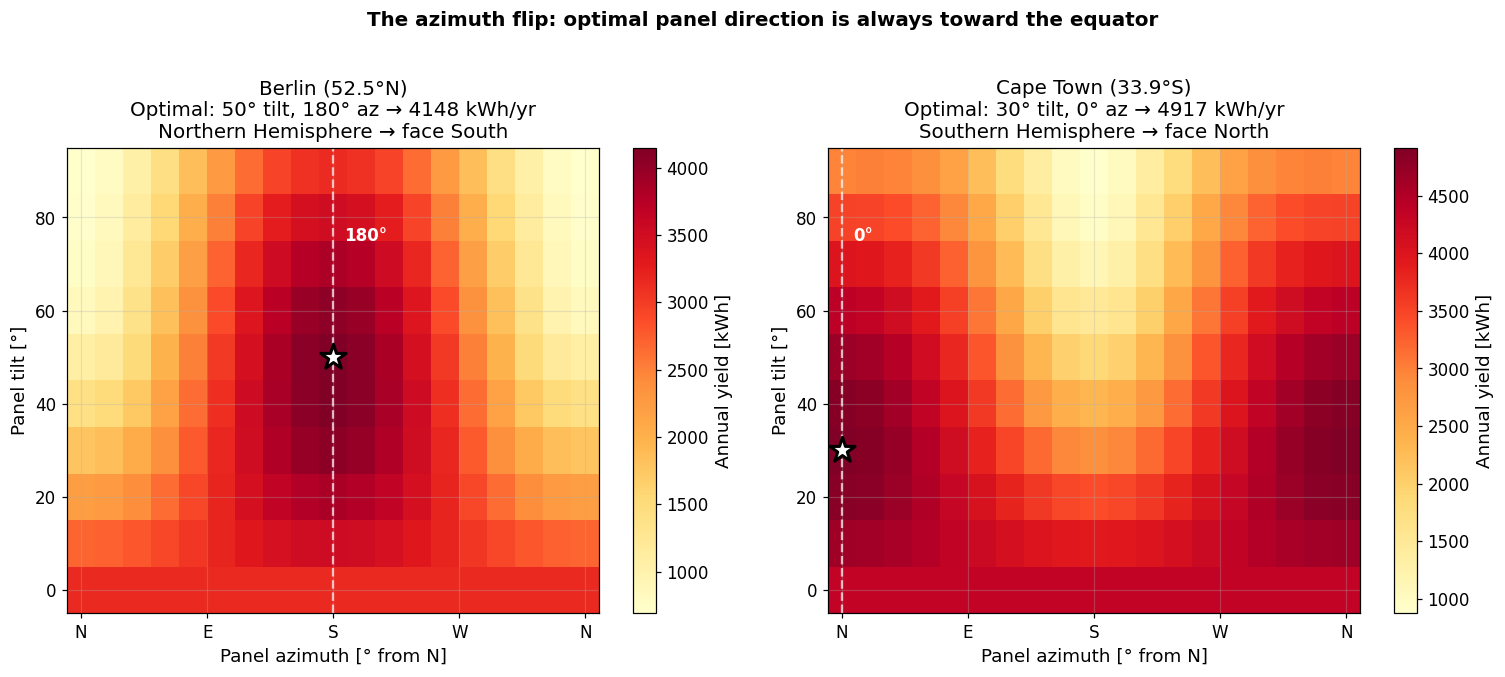

Berlin:    optimal azimuth ≈ 180° (South) — panels face the equator (N hemisphere)
Cape Town: optimal azimuth ≈   0° (North) — panels face the equator (S hemisphere)

General rule: optimal azimuth = toward the equator (180° in N, 0°/360° in S)
Optimal tilt  ≈ |latitude| − 10°  (lower than latitude to favour the longer summer days)


In [11]:
# ── The azimuth flip: Northern vs Southern Hemisphere ────────────────────
# Berlin (52.5°N) and Cape Town (33.9°S) side-by-side

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

locations = [
    ( 52.5, 0, 'Berlin (52.5°N)',    'Northern Hemisphere → face South'),
    (-33.9, 0, 'Cape Town (33.9°S)', 'Southern Hemisphere → face North'),
]

for ax, (lat, lon, city, rule) in zip(axes, locations):
    egrid = compute_annual_grid(lat, lon, 100, tilt_c, az_c,
                                 10.0, 0.20, 0.20, dt=1.0)
    i_o, j_o = np.unravel_index(np.argmax(egrid), egrid.shape)
    opt_t, opt_a, opt_e = tilt_c[i_o], az_c[j_o], egrid[i_o, j_o]

    im = ax.pcolormesh(az_c, tilt_c, egrid, cmap='YlOrRd', shading='auto')
    plt.colorbar(im, ax=ax, label='Annual yield [kWh]')
    ax.scatter([opt_a], [opt_t], s=300, marker='*',
                color='white', edgecolors='black', lw=2, zorder=5)
    ax.set_xticks([0, 90, 180, 270, 360])
    ax.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
    ax.set_xlabel('Panel azimuth [° from N]')
    ax.set_ylabel('Panel tilt [°]')
    ax.set_title(f'{city}\nOptimal: {opt_t}° tilt, {opt_a}° az → {opt_e:.0f} kWh/yr\n{rule}')
    # Mark the optimal azimuth with a vertical line
    ax.axvline(opt_a, color='white', lw=1.5, ls='--', alpha=0.7)
    ax.text(opt_a + 8, 75, f'{opt_a}°', color='white', fontsize=11, fontweight='bold')

plt.suptitle('The azimuth flip: optimal panel direction is always toward the equator',
              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Berlin:    optimal azimuth ≈ 180° (South) — panels face the equator (N hemisphere)')
print('Cape Town: optimal azimuth ≈   0° (North) — panels face the equator (S hemisphere)')
print()
print('General rule: optimal azimuth = toward the equator (180° in N, 0°/360° in S)')
print('Optimal tilt  ≈ |latitude| − 10°  (lower than latitude to favour the longer summer days)')


---

## Summary and Key Results

### The complete chain from photon to kilowatt-hour

We traced solar energy through five physical layers:

| Layer | Key equation | Key result |
|---|---|---|
| **Nuclear furnace** | $E = \Delta m\,c^2$ | $L_\odot = 3.828 \times 10^{26}$ W |
| **Inverse-square law** | $S_0 = L_\odot/(4\pi\,\text{AU}^2)$ | $S_0 = 1361$ W/m² |
| **Orbital mechanics** | $G_{\rm ext}(n) = S_0\,E_0(n)$ | $\pm 3.4\%$ seasonal variation |
| **Spherical geometry** | $\sin\alpha = \sin\varphi\sin\delta + \cos\varphi\cos\delta\cos\omega$ | Sun path depends on lat & season |
| **Beer-Lambert** | $\text{DNI} = G_{\rm ext} \times 0.7^{\text{AM}^{0.678}}$ | ~30% lost to atmosphere at AM1 |
| **Cosine law + geometry** | $G_T = \text{DNI}\cos\theta + \text{DHI}\frac{1+\cos\beta}{2} + \text{GHI}\rho\frac{1-\cos\beta}{2}$ | Orientation is the key free variable |
| **Semiconductor physics** | $P = A\,\eta\,G_T$ | Annual yield: 800–1800 kWh/kWp typical |

### Rules of thumb (clear-sky, Northern Hemisphere)

- **Optimal tilt** $\approx$ latitude minus 10–15° (to favour summer, when there is more daylight)
- **Optimal azimuth** = due South (180° from North) in the Northern Hemisphere; due North in the Southern Hemisphere
- **Sensitivity**: the annual yield curve is *flat* within ±15° of the optimal tilt — orientation errors are forgiving
- **East/West split**: a 50/50 east–west split (30° tilt each) loses only ~5% vs optimal south-facing, while better matching afternoon electricity demand
- **Altitude bonus**: +1000 m elevation gives roughly +3–5% in annual irradiance

### What this model omits

This is a **clear-sky** model. Real-world yields are typically **60–85%** of these values, depending on:
- Cloud cover and aerosol loading (local climate data needed)
- Inverter losses (typically 3–5%)
- Shading from trees, buildings, other panels
- Soiling and degradation
- Spectral mismatch and module non-uniformity

More sophisticated tools (PVGIS, SAM, PVsyst) fold in measured irradiance databases for precise yield forecasts. But the physics developed here underpins all of them — you now know where every term comes from.

---
*Derived from first principles: nuclear physics → orbital mechanics → spherical trigonometry → atmospheric optics → semiconductor physics.*

---

## From Theory to Practice — Solar Advisor

This notebook uses a **simplified clear-sky model** (Beer–Lambert / Meinel 1976 + Liu–Jordan diffuse)
for educational clarity. Real-world yield estimates require real climate data and a more complete
loss model. The **Solar Advisor** web app implements the full physics stack derived here.

| Feature | This notebook | Solar Advisor |
|---------|:-------------|:--------------|
| Climate data | Clear-sky (no clouds) | PVGIS TMY — 20+ year satellite average |
| Sky diffuse model | Liu–Jordan (isotropic) | Perez anisotropic |
| Cell temperature | NOCT (simplified) | Faiman model (PVsyst default) |
| Electrical model | PVWatts-style | PVsyst one-diode SDM |
| Loss budget | Not modelled | Soiling, LID, mismatch, wiring, inverter |
| Economics | Not included | NPV, IRR, LCOE, payback period |

Use the Solar Advisor for realistic yield estimates before sizing an actual system.

👉 **[Solar Advisor — solarflower.streamlit.app](https://solarflower.streamlit.app)**

---
*SPDX-FileCopyrightText: 2025 Robin Gutzen &lt;robin.gutzen@outlook.com&gt;  
SPDX-License-Identifier: AGPL-3.0-or-later*
